In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None

import pyfade

In [23]:
PUMP = 'A-12 2'
SOURCE = 'C:/Users/Heitor/Documents/PosDoc/code/EPIC/Dados/merged_data.csv'
#EXAMPLE_SIGNAL = 'ESP motor temperature'
EXAMPLE_SIGNAL = None

In [4]:
WAVELET = 'db2'
IGNORE_START = True
QUANTILE = 0.75
SUB_SIZE = 7*24
LEVELS = 3
DIMENSION = 2

# 1 - Reading Signal

In [24]:
# Load well data
data_full = pyfade.load_data(SOURCE)
well_data = pyfade.get_well_data(data_full, PUMP, only_numerical=True, remove_ints=True, drop_na=True, drop_features = True)

shutdowns_all = pyfade.get_shutdowns(well_data)

In [6]:
#fig, axs = pyfade.plot_multiple(well_data,style='.b',shutdowns=shutdowns_all);

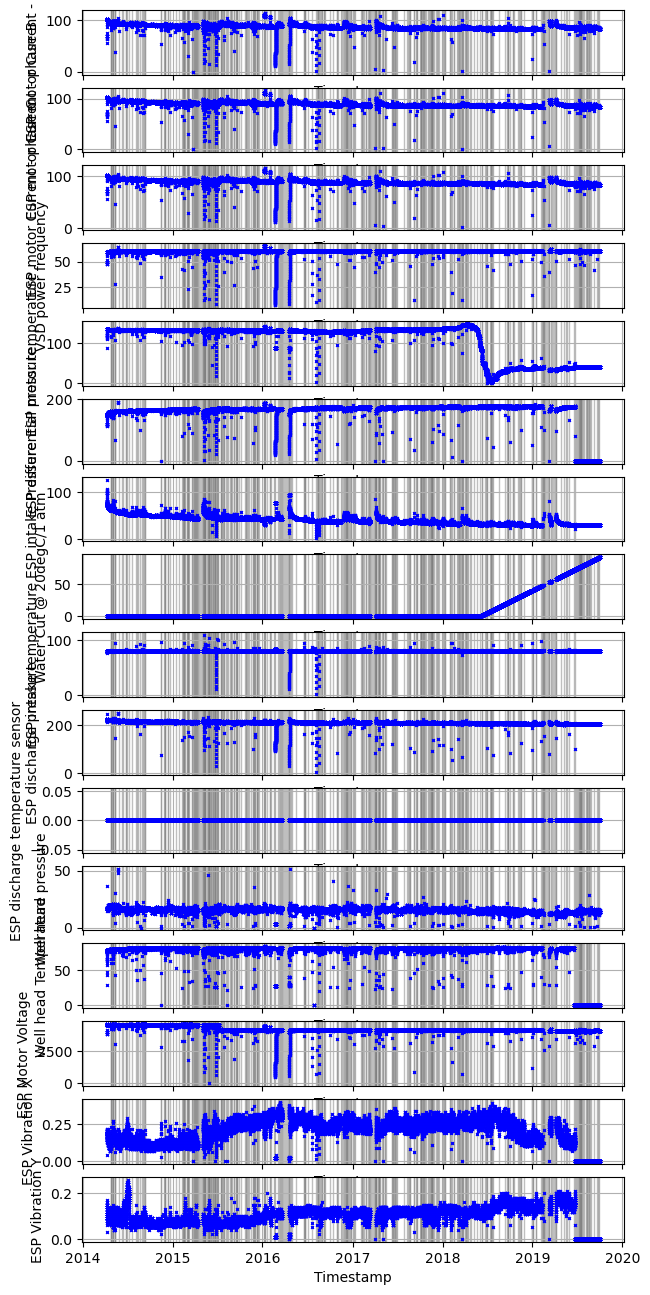

In [25]:
if EXAMPLE_SIGNAL is not None:
    sub_data = well_data[EXAMPLE_SIGNAL]
    shutdowns = [shutdowns_all[well_data.columns.get_loc(EXAMPLE_SIGNAL)]]
else:
    sub_data = well_data.copy()
    shutdowns = shutdowns_all

sub_data.interpolate(method='linear',inplace=True)
sub_data.dropna(inplace=True)


fig, axs = pyfade.plot_multiple(sub_data,style='xb',markersize=2,shutdowns=shutdowns);

# 2 - MP raw

In [26]:
n_data = pyfade.znormalize(sub_data)

In [27]:
MP = pyfade.get_MP(n_data,SUB_SIZE,ignore_start=IGNORE_START, quantile=QUANTILE,shutdowns=shutdowns,normalize=False)

print(SUB_SIZE,sub_data.size)

c:\Users\Heitor\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
c:\Users\Heitor\anaconda3\Lib\site-packages\pyfade\mprofile.py:341: RuntimeWarning: invalid value encountered in less
  mp[:,0][mp[:,0]<0] = 0


168 658432


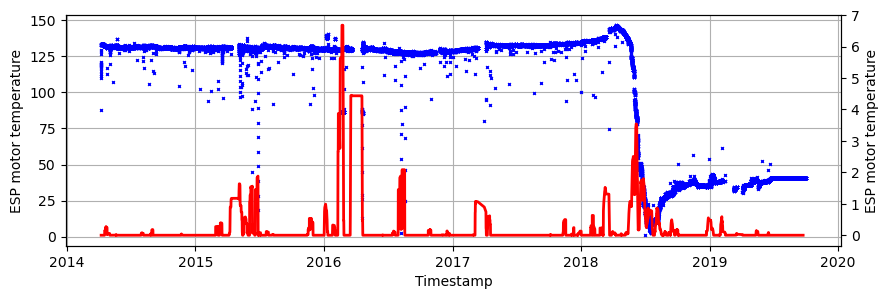

In [18]:
fig, axs = pyfade.plot_multiple(sub_data,style='xb',shutdowns=None,markersize=2,height=3,width=10);
pyfade.plot_multiple(MP,fig=fig,axs=axs,style='r-',linewidth=2);

In [15]:
MP = pyfade.get_MP(pyfade.znormalize(sub_data),SUB_SIZE,ignore_start=IGNORE_START, quantile=QUANTILE,shutdowns=shutdowns,normalize=True,stump=False)

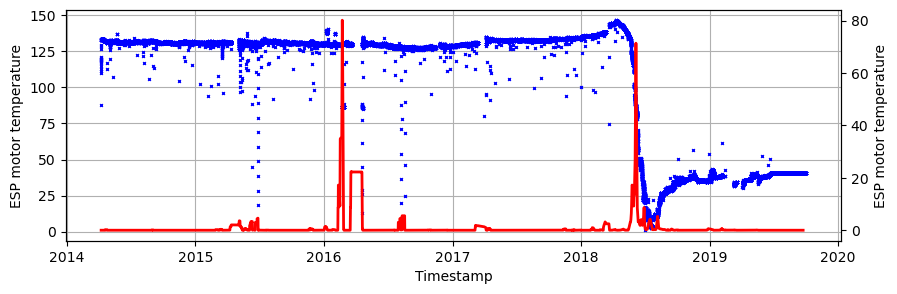

In [16]:
fig, axs = pyfade.plot_multiple(sub_data,style='xb',shutdowns=None,markersize=2,height=3,width=10);
pyfade.plot_multiple(MP,fig=fig,axs=axs,style='r-',linewidth=2);

# 3 - Decomposition

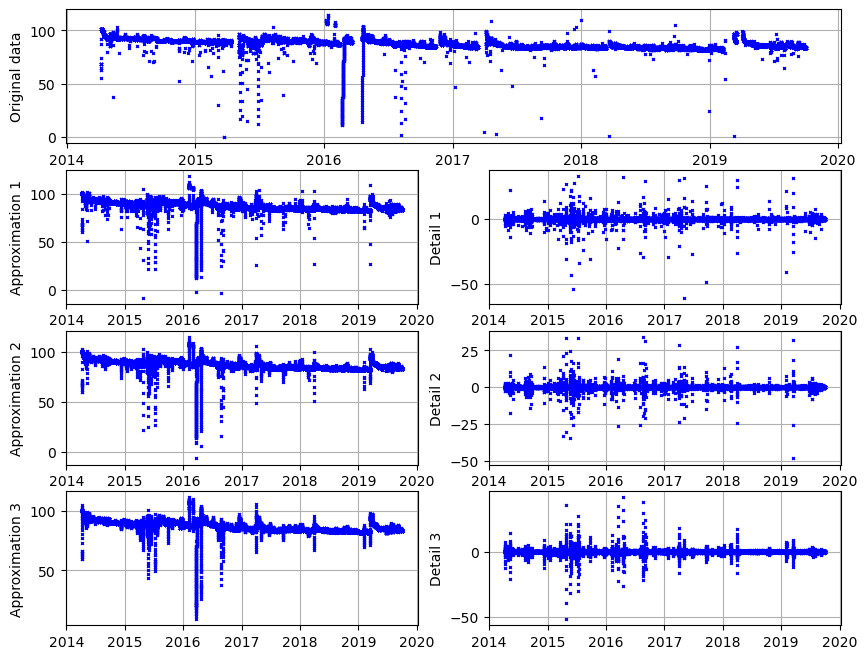

In [37]:
pyfade.get_signal_decomp(sub_data,wavelet=WAVELET, create_plot=True, level = LEVELS, height= 2, width= 10,markersize=2,style='xb');

# 4 - MP wavelet

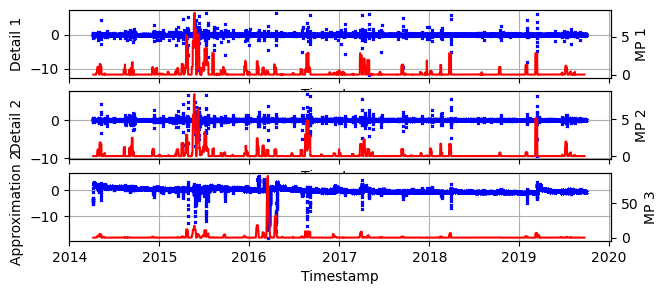

In [38]:
MP_wave, _ =  pyfade.get_MP_from_wavelets(sub_data,SUB_SIZE,DIMENSION, wavelet=WAVELET,on_signals=True,create_plot=True,plot_data=True,ignore_start=IGNORE_START, quantile=QUANTILE,shutdowns=shutdowns,height=2, width=10,markersize=2,style=['r-','xb'])

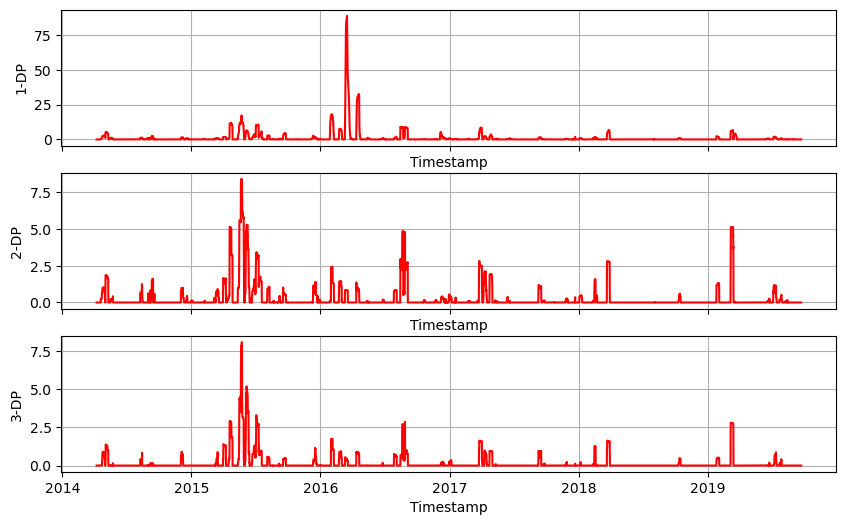

In [39]:
KDP = pyfade.get_KDP(sub_data,SUB_SIZE,pre_calc_MP=MP_wave,shutdowns=shutdowns)
fig, axs = pyfade.plot_multiple(KDP,same_limits=False,style='r-',height=2, width=10);

In [44]:
sub_data.drop('ESP discharge temperature sensor',inplace=True,axis=1)
MPs = pyfade.wavelet_MP_from_KDP(sub_data,SUB_SIZE,DIMENSION,level=LEVELS,wavelet=WAVELET,ignore_start=IGNORE_START, quantile=QUANTILE, on_signals=True,shutdowns=shutdowns)

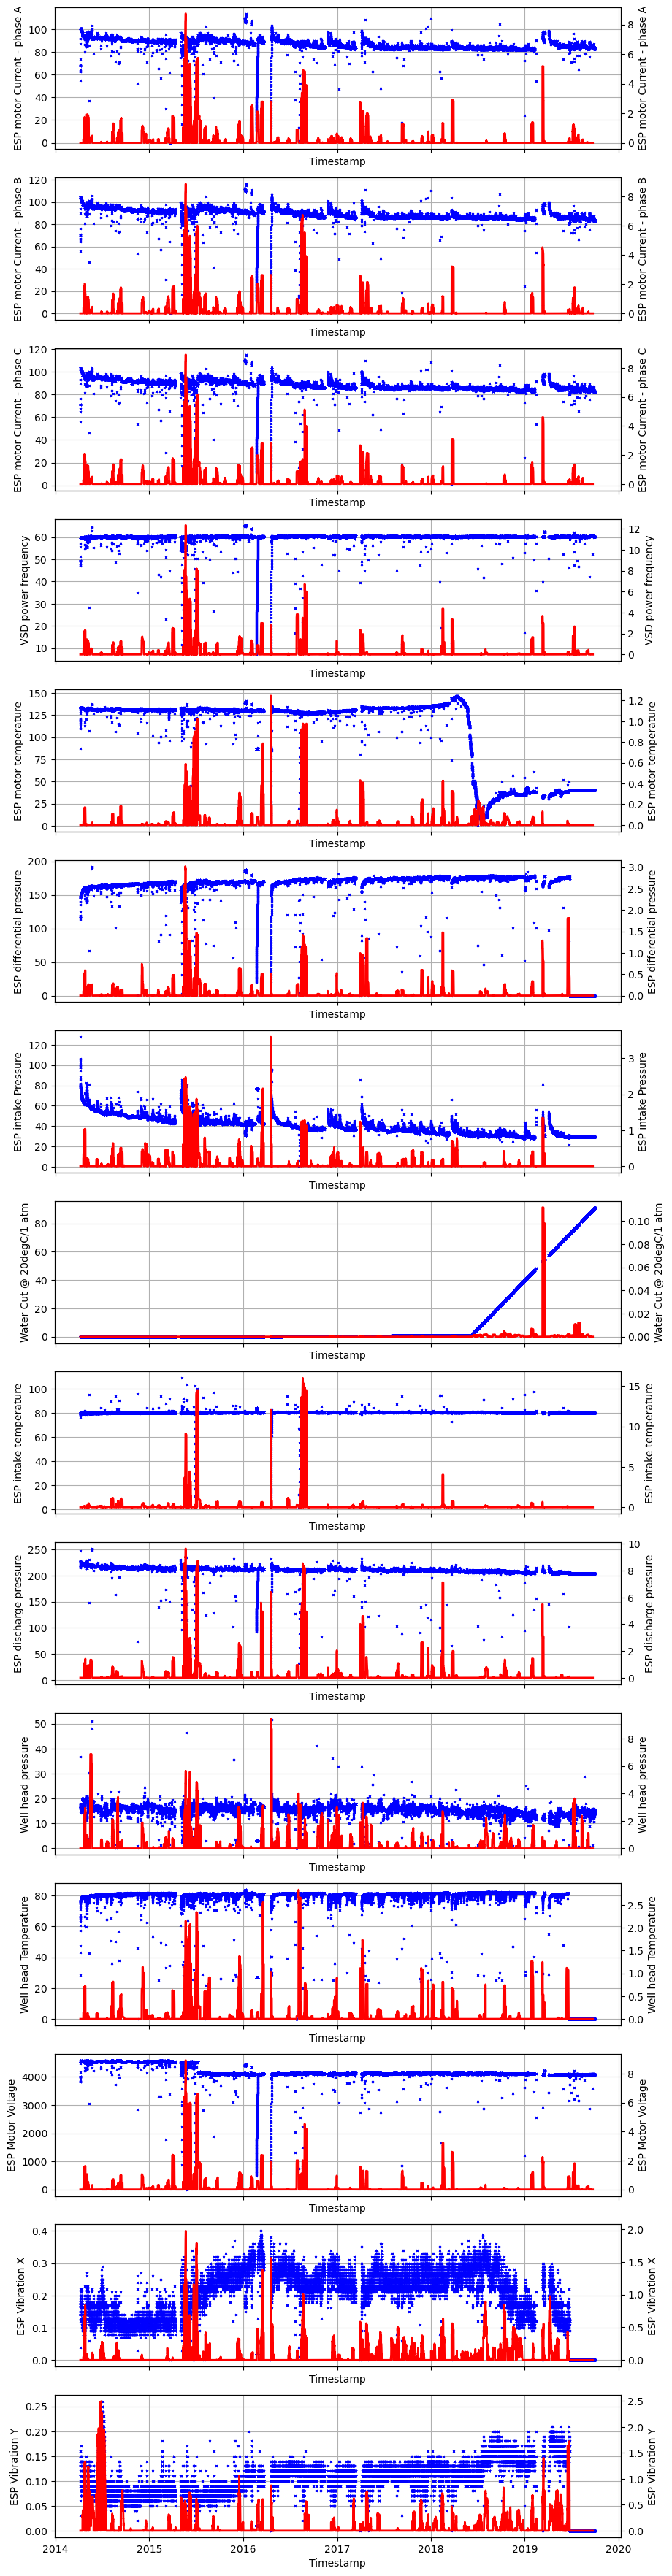

In [48]:
fig, axs = pyfade.plot_multiple(sub_data,style='xb',markersize=2,height=3, width=10);
pyfade.plot_multiple(MPs,fig=fig,axs=axs,style='r-',linewidth=2);

In [55]:
fig.savefig('All_MP.png', format='png', dpi=300)

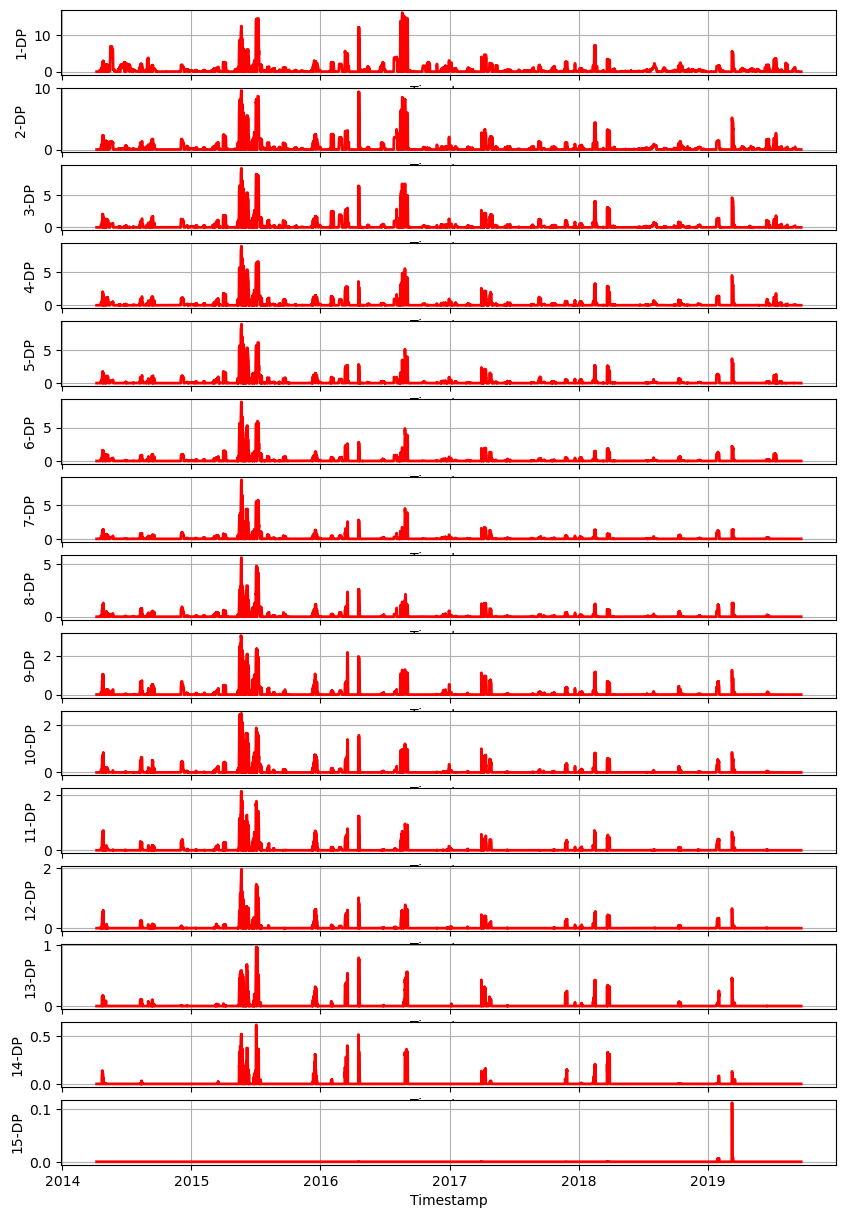

In [57]:
KDP = pyfade.get_KDP(sub_data,SUB_SIZE,pre_calc_MP=MPs,shutdowns=shutdowns)
fig, axs = pyfade.plot_multiple(KDP,same_limits=False,height=1, width=10,linewidth=2,style='r-');

In [58]:
fig.savefig('All_KDP.png', format='png', dpi=300)